In [1]:
import numpy as np
import torch as pt
import nibabel as nb
import nitools as nt
import pandas as pd
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
import Functional_Fusion.dataset as ds
import HierarchBayesParcel.arrangements as ar
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
import HierarchBayesParcel.util as ut
import SUITPy as suit
from py_util_dx.py_utils import setProjectPath
import os, pickle
import IndividualParcellation
from nitools.cifti import surf_from_cifti
import SUITPy.flatmap as flatmap

/home/UWO/jxiang27/pfc_parcellation/lib/python3.10/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
/home/UWO/jxiang27/pfc_parcellation/lib/python3.10/site-packages/torch/__init__.py:1236: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:434.)
  _C._set_default_tensor_type(t)


In [2]:
projectPath, mainResultsPath = setProjectPath()

dataset_name = 'MDTB' # or Demand

resultsPath = os.path.join(mainResultsPath, 'START_A5_bayes_parcellation', dataset_name)
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')

PKL_output = os.path.join(resultsPath, 'output.pkl')
output = {}

In [3]:
# Get the atlas
atlas_str = 'fs32k'
atlas, ainf = am.get_atlas(atlas_str)

# Sample the probabilistic atlas at the specific atlas grayordinates
# atlas_fname = os.path.join(surface_helpers_dir, 'atl-NettekovenSym32_space-MNI152NLin2009cSymC_probseg.nii.gz')
atlas_fname = [os.path.join(surface_helpers_dir, 'glasser.L.label.gii'), os.path.join(surface_helpers_dir, 'glasser.R.label.gii')]
U = atlas.read_data(atlas_fname)
U = U.T

# converting the hard parcellation into a probabilistic one
U = IndividualParcellation.utils.convert_hard_to_prob(U, strength=7.0)

# Build the arrangement model - the parameters are the log-probabilities of the atlas
# ar_model = ar.build_arrangement_model(U, prior_type='prob', atlas=atlas)
ar_model = ar.build_arrangement_model(U, prior_type='logpi', atlas=atlas, sym_type='sym')

# loading MDTB data
PKL_data = os.path.join(projectPath, 'data', f'{dataset_name}_Cond_Half.pkl')
with open(PKL_data, 'rb') as pf:
    original_data = pickle.load(pf)
    data = original_data['X_individuals']
    info_individuals = original_data['info_individuals']
    dataset_obj_individuals = original_data['dataset_obj_individuals']

cond_vec = np.array(list(info_individuals[dataset_obj_individuals.cond_ind]))
part_vec = np.array(list(info_individuals[dataset_obj_individuals.part_ind]))

# fit the emission model to the data
# K is the number of parcels
K = ar_model.K
# Make a design matrix
X= ut.indicator(cond_vec)
# Build an emission model
em_model = em.MixVMF(K=K,P=atlas.P, X=X,part_vec=part_vec)
# Build the full model: The emission models are passed as a list, as usually we have multiple data sets
M = fm.FullMultiModel(ar_model, [em_model])
# Attach the data to the model - this is done for speed
# The data is passed as a list with on element per data set
M.initialize([data])

# Now we can run the EM algorithm
# M, _, _, _ = M.fit_em(iter=200, tol=0.01, fit_arrangement=False,fit_emission=True,first_evidence=False)
M, _, _, U_indiv = M.fit_em(iter=200, tol=0.01, fit_arrangement=False,fit_emission=True,first_evidence=False)

# M.initialize([data])
# U_indiv, _ = M.Estep()


# saving U and U_indiv
output['U'] = U
output['U_indiv'] = U_indiv

with open(PKL_output, 'wb') as pf:
    pickle.dump(output, pf)

# loading saved U and U_indiv
with open(PKL_output, 'rb') as pf:
    output = pickle.load(pf)

U = output['U']
U_indiv = output['U_indiv']

In [4]:
# Load colormap and labels
# lid,cmap,names = nt.read_lut('atl-NettekovenSym32.lut')
lid,cmap,names = nt.read_lut(os.path.join(surface_helpers_dir, 'atl-glasser.lut'))

flat_surf_L = os.path.join(surface_helpers_dir, 'fs_LR.32k.L.flat.surf.gii')
flat_surf_R = os.path.join(surface_helpers_dir, 'fs_LR.32k.R.flat.surf.gii')
border_LR = os.path.join(surface_helpers_dir, 'fs_LR.32k.L.border')

In [5]:
def plot_probseg(surf_data, cmap, hemi):
    label = np.argmax(surf_data, axis=0)+1
    [label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(label.reshape(1, -1)))

    if hemi == 'L':
        # left cortex
        flatmap.plot(label_L.reshape(-1, ),
                     surf=flat_surf_L,
                     underlay=os.path.join(surface_helpers_dir, 'sub-01.L.sulc.32k_fs_LR.shape.gii'),
                     alpha=1,
                     label_names=names,
                     new_figure=False,
                     frame=None,
                     render='matplotlib',
                     cmap=cmap,
                     borders=border_LR,
                     # cscale=[0,31],
                     overlay_type='label',
                     bordersize=3,
        )

    else:
        # right cortex
        flatmap.plot(label_R.reshape(-1, ),
                     surf=flat_surf_R,
                     underlay=os.path.join(surface_helpers_dir, 'sub-01.R.sulc.32k_fs_LR.shape.gii'),
                     alpha=1,
                     label_names=names,
                     new_figure=False,
                     frame=None,
                     render='matplotlib',
                     cmap=cmap,
                     borders=border_LR,
                     # cscale=[0, 31],
                     overlay_type='label',
                     bordersize=3,
        )

/home/UWO/jxiang27/jxiang27_beluga/projects/def-hallett-ab/jxiang27/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/home/UWO/jxiang27/jxiang27_beluga/projects/def-hallett-ab/jxiang27/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)


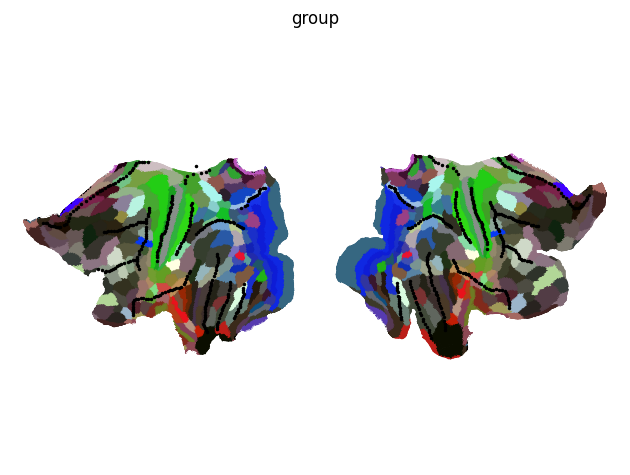

In [6]:
# Make a nifti image of the group
surf_data = U.detach().numpy()

# plot the group probabilistic atlas
plt.figure()
plt.subplot(1, 2, 1)
plot_probseg(surf_data, cmap, 'L')
plt.subplot(1, 2, 2)
plot_probseg(surf_data, cmap, 'R')
plt.suptitle('group')
plt.tight_layout()

/home/UWO/jxiang27/jxiang27_beluga/projects/def-hallett-ab/jxiang27/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/home/UWO/jxiang27/jxiang27_beluga/projects/def-hallett-ab/jxiang27/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/home/UWO/jxiang27/jxiang27_beluga/projects/def-hallett-ab/jxiang27/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/home/UWO/jxiang27/jxiang27_beluga/projects/def-hallett-ab/jxiang27/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/home/UWO/jxiang27/jxiang27_beluga/projects/def-hallett-ab/jxiang27/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/home/UWO/jxiang27/jxiang

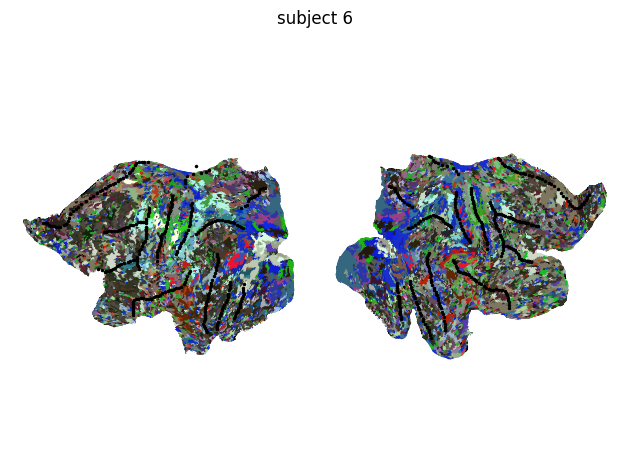

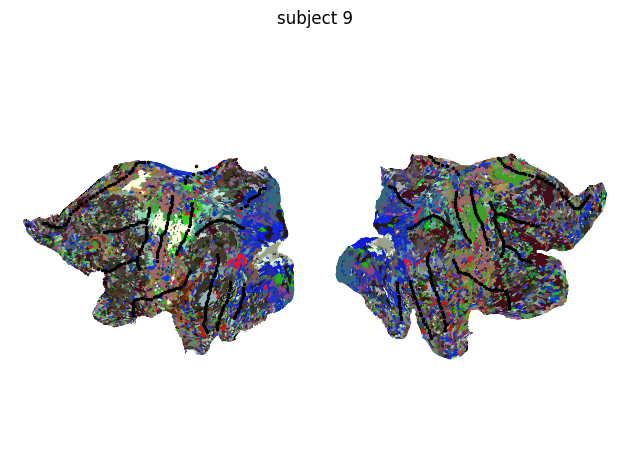

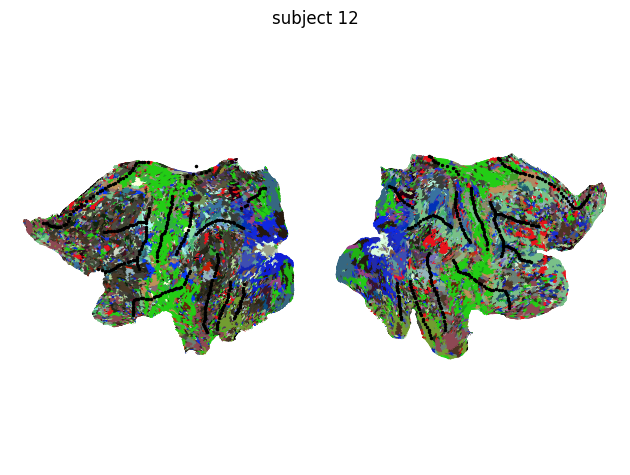

In [7]:
# plot 3 individual subjects
for i,s in enumerate([6,9,12]):
    surf_data = U_indiv[s].detach().numpy()

    plt.figure()
    plt.subplot(1, 2, 1)
    plot_probseg(surf_data, cmap, 'L')
    plt.subplot(1, 2, 2)
    plot_probseg(surf_data, cmap, 'R')
    plt.suptitle(f'subject {s}')
    plt.tight_layout()